# Analiza danych pracowników

Autor: Karol Ab
Data: 2026-07-11

## Cel analizy
1. Czy istnieje zależność pomiędzy tym, kto jest bezpośrednim przełożonym (ManagerName, ManagerID) danego pracownika, a oceną wydajności pracy (PerformanceScore)?
2. Jakie źródła pozyskania pracownika (Recruitment Source) są najlepsze, jeśli zależy nam na jak najdłuższym stażu pracowników?
3. Czy stan cywilny (MartialDesc) pracownika koreluje w jakikolwiek sposób z zadowoleniem z pracy (EmpSatisfaction)?
4. Jak wygląda struktura wieku aktualnie zatrudnionych pracowników?
5. Czy starsi pracownicy pracują nad większą liczbą specjalnych projektów niż młodsi pracownicy?


In [250]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
pd.set_option("display.max_colwidth", None)

## Wczytywanie danych

In [251]:
df = pd.read_csv("HRDataset.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,PayRate,...,Department,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30
0,"Brown, Mia",1.103024e+09,1.0,1.0,0.0,1.0,1.0,3.0,1.0,28.50,...,Admin Offices,Brandon R. LeBlanc,1.0,Diversity Job Fair,Fully Meets,2.04,2.0,6.0,1/15/2019,0.0
1,"LaRotonda, William",1.106027e+09,0.0,2.0,1.0,1.0,1.0,3.0,0.0,23.00,...,Admin Offices,Brandon R. LeBlanc,1.0,Website Banner Ads,Fully Meets,5.00,4.0,4.0,1/17/2019,0.0
2,"Steans, Tyrone",1.302053e+09,0.0,0.0,1.0,1.0,1.0,3.0,0.0,29.00,...,Admin Offices,Brandon R. LeBlanc,1.0,Internet Search,Fully Meets,3.90,5.0,5.0,1/18/2019,0.0
3,"Howard, Estelle",1.211051e+09,1.0,1.0,0.0,1.0,1.0,3.0,0.0,21.50,...,Admin Offices,Brandon R. LeBlanc,1.0,Pay Per Click - Google,Fully Meets,3.24,3.0,4.0,NaN,NaN
4,"Singh, Nan",1.307060e+09,0.0,0.0,0.0,1.0,1.0,3.0,0.0,16.56,...,Admin Offices,Brandon R. LeBlanc,1.0,Website Banner Ads,Fully Meets,5.00,3.0,5.0,1/15/2019,0.0


In [252]:
df["LastPerformanceReview_Date"] = pd.to_datetime(df["LastPerformanceReview_Date"])
df["LastPerformanceReview_Date"].max()

Timestamp('2019-02-28 00:00:00')

## Przygotowanie danych

In [253]:

# Ustalenie daty odniesienia dla danych
df["LastPerformanceReview_Date"] = pd.to_datetime(df["LastPerformanceReview_Date"])
df["LastPerformanceReview_Date"].max()
reference_date = pd.Timestamp("2019-02-28")
# Zamiana dat
df["DateofHire"] = pd.to_datetime(df["DateofHire"])

# Staż pracy (lata)
df["Seniority"] = (
    reference_date - df["DateofHire"]
).dt.days / 365

# Dodanie wieku
df["DOB"] = pd.to_datetime(df["DOB"], format="%m/%d/%y")
df.loc[df["DOB"] > reference_date, "DOB"] -= pd.DateOffset(years=100)
today = reference_date
df["Age"] = (
    today.year
    - df["DOB"].dt.year
    - (
        (today.month < df["DOB"].dt.month)
        | (
            (today.month == df["DOB"].dt.month)
            & (today.day < df["DOB"].dt.day)
        )
    )
)

## 1. Czy istnieje zależność pomiędzy tym, kto jest bezpośrednim przełożonym (ManagerName, ManagerID) danego pracownika, a oceną wydajności pracy (PerformanceScore)?


PerformanceScore wg Managera
PerformanceScore    Exceeds  Fully Meets  Needs Improvement  PIP
ManagerName                                                     
Alex Sweetwater           2            6                  1    0
Amy Dunn                  3           15                  1    2
Board of Directors        0            2                  0    0
Brandon R. LeBlanc        0            7                  0    0
Brannon Miller            7            9                  1    4
Brian Champaigne          0            8                  0    0
David Stanley             1           19                  1    0
Debra Houlihan            0            2                  1    0
Elijiah Gray              2           18                  2    0
Eric Dougall              1            3                  0    0
Janet King                4           13                  2    0
Jennifer Zamora           2            4                  1    0
John Smith                0           12                  0 

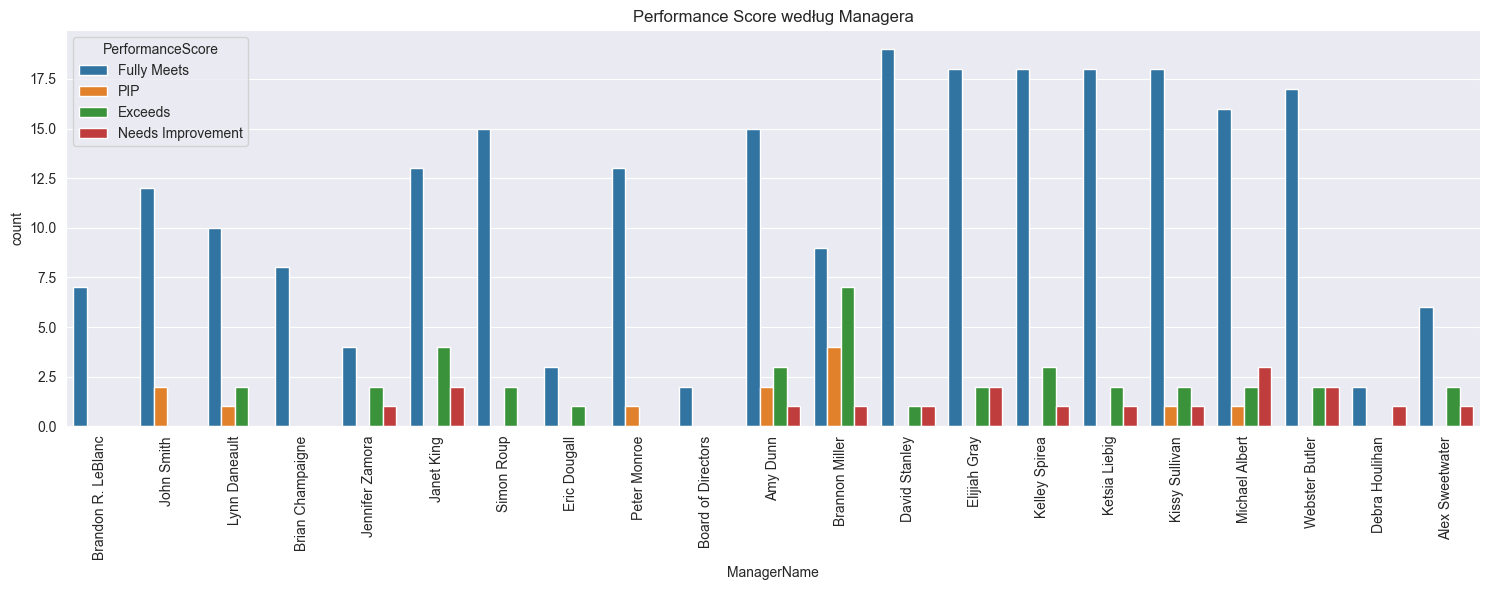

In [254]:
plt.figure(figsize=(15,6))

sns.countplot(
    data=df,
    x="ManagerName",
    hue="PerformanceScore"
)

plt.xticks(rotation=90)
plt.title("Performance Score według Managera")
plt.tight_layout()

print("\nPerformanceScore wg Managera")
print(pd.crosstab(df["ManagerName"], df["PerformanceScore"]))

Wnioski: Nie widać szczególnych różnic między managerami. Wyjątkiem jest Brandon Miller którego oceny mają największą rozbieżność od dużej ilości ocen Exceeds do PIP ale pytanie jaki zespół prowadzi potrzebna by byłą dalsza analiza. Dla Pozostałych zespołów większość pracowników spełnia oczekiwania.

In [255]:
set(df["ManagerName"]) - set(df["Employee_Name"])

{'Alex Sweetwater',
 'Amy Dunn',
 'Board of Directors',
 'Brandon R. LeBlanc',
 'Brannon Miller',
 'Brian Champaigne',
 'David Stanley',
 'Debra Houlihan',
 'Elijiah Gray',
 'Eric Dougall',
 'Janet King',
 'Jennifer Zamora',
 'John Smith',
 'Kelley Spirea',
 'Ketsia Liebig',
 'Kissy Sullivan',
 'Lynn Daneault',
 'Michael Albert',
 'Peter Monroe',
 'Simon Roup',
 'Webster Butler'}

Managerowie nie znajdują się w zbiorze danych więc ciężko określić kim jest Brandon Miller, wtedy można by szukać powiązań między ocenami managerów.

In [256]:
df.groupby("ManagerName")["Position"].unique()


ManagerName
Alex Sweetwater                                                                                                       [Software Engineer]
Amy Dunn                                                                              [Production Technician I, Production Technician II]
Board of Directors                                                                                      [President & CEO, Sr. Accountant]
Brandon R. LeBlanc                                                               [Accountant I, Administrative Assistant, Sr. Accountant]
Brannon Miller                                                                        [Production Technician I, Production Technician II]
Brian Champaigne                                                                      [BI Developer, Data Architect, Senior BI Developer]
David Stanley                                                                         [Production Technician I, Production Technician II]
Debra Houlihan        

Tutaj można się przyjrzeć lepiej strukturze zespołów ale inni managerowie mający pod sobą podobny skład i ich oceny nie odbiegają znacząco od siebie.

In [257]:
brannon = (
    df[df["ManagerName"] == "Brannon Miller"]
    [
        [
            "Employee_Name",
            "Position",
            "RaceDesc",
            "Sex",
            "Age",
            "Seniority",
            "EmpSatisfaction",
            
            "PerformanceScore"
        ]
    ]
)

brannon = brannon.sort_values(
    by=["PerformanceScore", "Seniority"]
)
display(brannon)

,Employee_Name,Position,RaceDesc,Sex,Age,Seniority,EmpSatisfaction,PerformanceScore
105,"Clukey, Elijian",Production Technician I,White,M,38.0,2.649315,4.0,Exceeds
104,"Billis, Helen",Production Technician I,White,F,29.0,4.649315,3.0,Exceeds
232,"Johnston, Yen",Production Technician II,White,F,49.0,4.649315,3.0,Exceeds
114,"Robinson, Elias",Production Technician I,White,M,34.0,5.646575,5.0,Exceeds
112,"Ngodup, Shari",Production Technician I,Asian,F,51.0,5.915068,3.0,Exceeds
235,"Winthrop, Jordan",Production Technician II,White,M,60.0,6.145205,3.0,Exceeds
108,"Gonzalez, Cayo",Production Technician I,American Indian or Alaska Native,M,49.0,7.641096,4.0,Exceeds
111,"Mangal, Debbie",Production Technician I,White,F,44.0,5.301370,3.0,Fully Meets
109,"Ivey, Rose",Production Technician I,White,F,28.0,5.531507,3.0,Fully Meets
116,"Tippett, Jeanette",Production Technician I,Black or African American,F,51.0,6.030137,5.0,Fully Meets


Patrząc na Performance Score nie widać szczególnych zależności poza tym że osoby mające ocenę PIP mają niski EmpSatisfaction i może stażem pracy.

In [258]:
pd.crosstab(
    df["PerformanceScore"],
    df["EmpSatisfaction"]
)

EmpSatisfaction,1.0,2.0,3.0,4.0,5.0
PerformanceScore,,,,,
Exceeds,0,0,11,11,15
Fully Meets,0,1,87,77,78
Needs Improvement,0,2,7,5,4
PIP,2,6,3,0,1


Widać zależność między satysfakcją a oceną dla całego zakładu. Nie jest to jednak chyba nic nadzwyczajnego

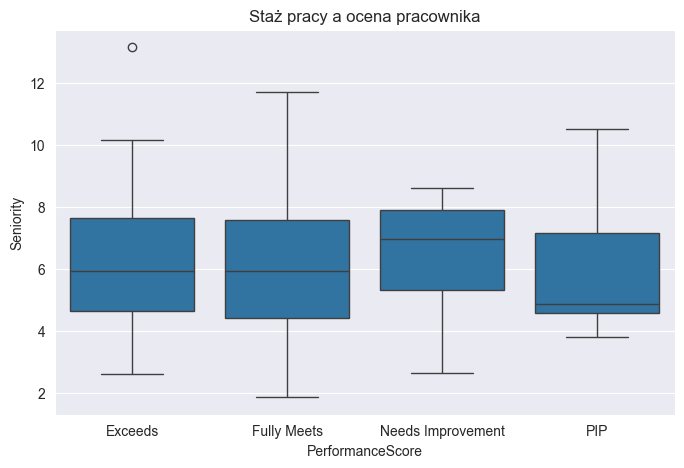

In [259]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="PerformanceScore",
    y="Seniority",
    order=["Exceeds","Fully Meets","Needs Improvement","PIP"]
)

plt.title("Staż pracy a ocena pracownika")
plt.show()

Sam staż pracy raczej nie tłumaczy oceny pracownika.

<Axes: xlabel='PerformanceScore', ylabel='Seniority'>

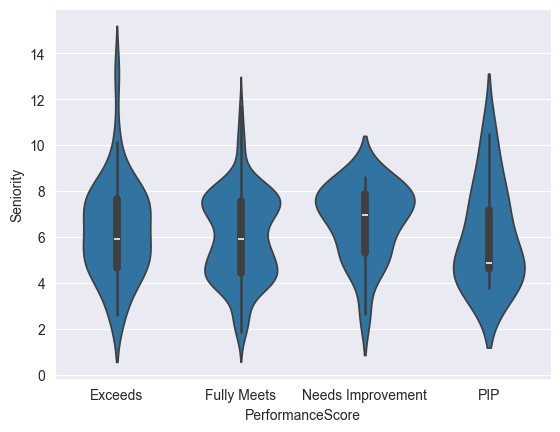

In [268]:
sns.violinplot(
    data=df,
    x="PerformanceScore",
    y="Seniority",
    order=["Exceeds", "Fully Meets", "Needs Improvement", "PIP"]
)

Staż sam w sobie nie jest dobrym predyktorem PerformanceScore.

2. Jakie źródła pozyskania pracownika (Recruitment Source) są najlepsze, jeśli zależy nam na jak najdłuższym stażu pracowników?


Średni staż wg źródła rekrutacji
RecruitmentSource
Other                                     7.978082
Careerbuilder                             7.909589
Social Networks - Facebook Twitter etc    7.529514
Search Engine - Google Bing Yahoo         7.376658
Billboard                                 7.170548
Diversity Job Fair                        7.071233
Word of Mouth                             6.819389
Monster.com                               6.516324
Pay Per Click                             6.432877
On-line Web application                   6.432877
MBTA ads                                  6.346817
Internet Search                           6.031507
Information Session                       5.960274
Newspager/Magazine                        5.935921
Glassdoor                                 5.878865
Pay Per Click - Google                    5.799609
Website Banner Ads                        5.459431
Professional Society                      5.398767
Employee Referral             

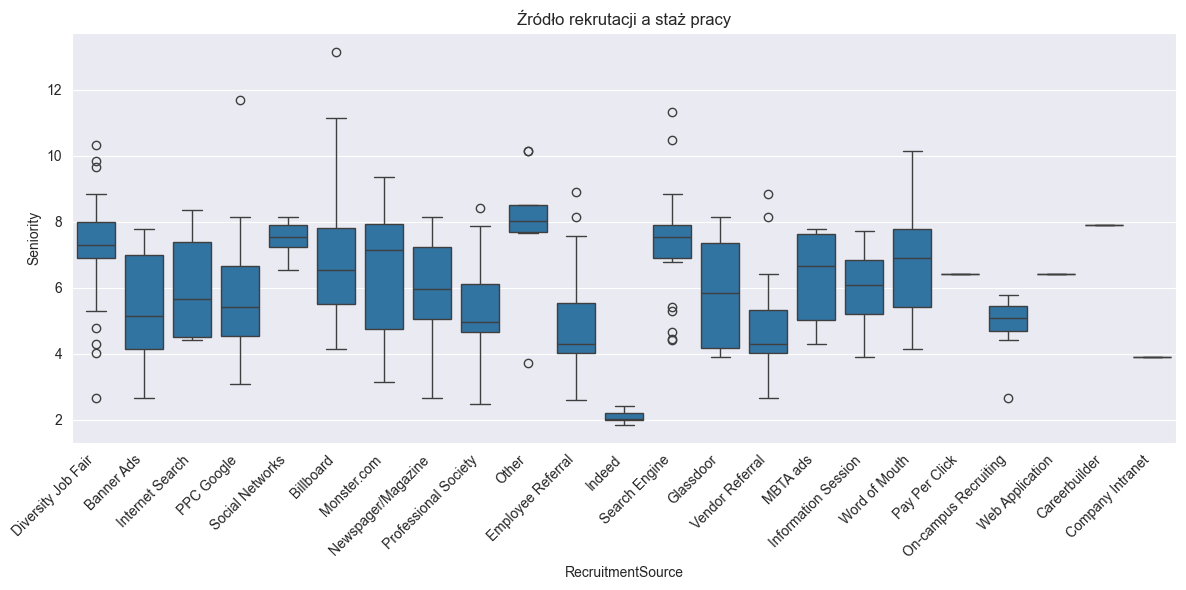

In [269]:
plt.figure(figsize=(12,6))

labels = {
    "Social Networks - Facebook Twitter etc": "Social Networks",
    "Search Engine - Google Bing Yahoo": "Search Engine",
    "Pay Per Click - Google": "PPC Google",
    "Company Intranet - Partner": "Company Intranet",
    "On-line Web application": "Web Application",
    "Website Banner Ads": "Banner Ads"
}

plot_df = df.copy()
plot_df["RecruitmentSource"] = plot_df["RecruitmentSource"].replace(labels)

sns.boxplot(
    data=plot_df,
    x="RecruitmentSource",
    y="Seniority"
)

plt.xticks(rotation=45, ha="right")
plt.title("Źródło rekrutacji a staż pracy")
plt.tight_layout()

print("\nŚredni staż wg źródła rekrutacji")
print(
    df.groupby("RecruitmentSource")["Seniority"]
      .mean()
      .sort_values(ascending=False)
)

In [270]:
df["EmploymentStatus"].value_counts()

EmploymentStatus
Active                    182
Voluntarily Terminated     88
Terminated for Cause       15
Leave of Absence           14
Future Start               11
Name: count, dtype: int64

In [271]:
df["Termd"].value_counts()

Termd
0.0    207
1.0    103
Name: count, dtype: int64

<Axes: xlabel='Seniority', ylabel='Count'>

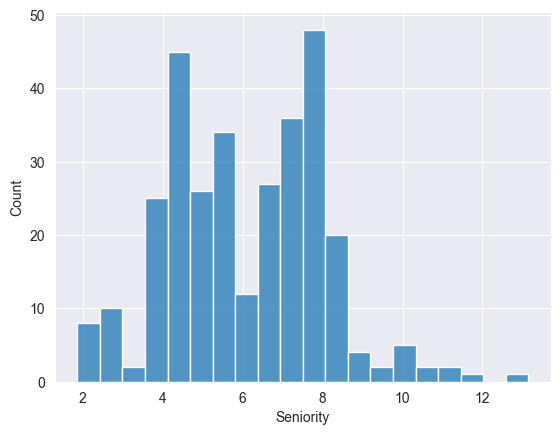

In [272]:
sns.histplot(df["Seniority"], bins=20)

In [273]:
df.groupby("RecruitmentSource")["Seniority"].describe()

,count,mean,std,min,25%,50%,75%,max
RecruitmentSource,,,,,,,,
Billboard,16.0,7.170548,2.454423,4.150685,5.502740,6.547945,7.804110,13.145205
Careerbuilder,1.0,7.909589,NaN,7.909589,7.909589,7.909589,7.909589,7.909589
Company Intranet - Partner,1.0,3.920548,NaN,3.920548,3.920548,3.920548,3.920548,3.920548
Diversity Job Fair,29.0,7.071233,1.694068,2.654795,6.912329,7.315068,7.986301,10.345205
Employee Referral,31.0,4.939726,1.471772,2.608219,4.035616,4.304110,5.531507,8.893151
Glassdoor,14.0,5.878865,1.607311,3.920548,4.189041,5.838356,7.358219,8.139726
Indeed,8.0,2.100000,0.213005,1.860274,1.991781,2.042466,2.208904,2.408219
Information Session,4.0,5.960274,1.604383,3.920548,5.215068,6.097260,6.842466,7.726027
Internet Search,6.0,6.031507,1.731468,4.419178,4.515068,5.671233,7.378082,8.350685


Wnioski: Zadanie jest trudne do określenia ponieważ dane wskazują, że np Indeed było jedyną formą zatrudniania dla pracowników w okresie ostatnich kilku latach, jak również pozostałem żródła pozyskania pracownika miały swoją okresowość. 

3. Czy stan cywilny (MartialDesc) pracownika koreluje w jakikolwiek sposób z zadowoleniem z pracy (EmpSatisfaction)?


Średnia satysfakcja
MaritalDesc
Divorced     4.033333
Married      3.747967
Separated    3.833333
Single       3.970803
Widowed      4.250000
Name: EmpSatisfaction, dtype: float64


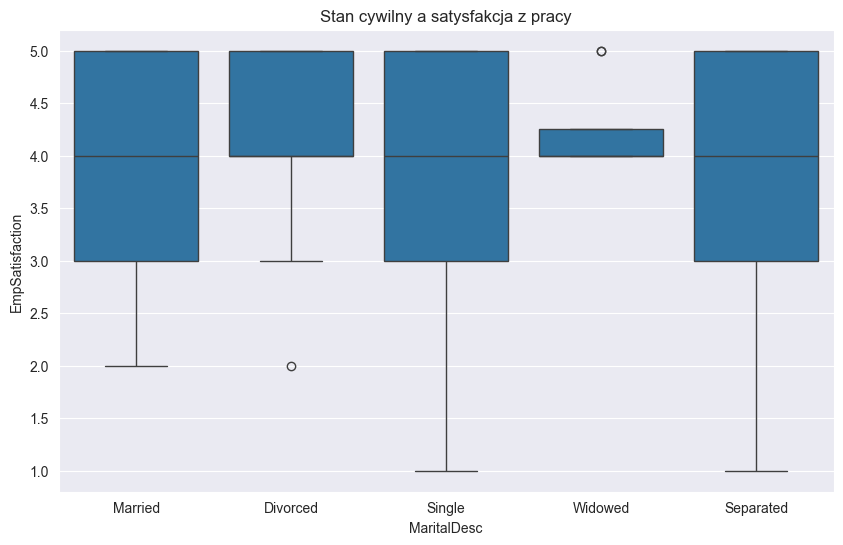

In [274]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="MaritalDesc",
    y="EmpSatisfaction"
)

plt.title("Stan cywilny a satysfakcja z pracy")

print("\nŚrednia satysfakcja")
print(
    df.groupby("MaritalDesc")["EmpSatisfaction"]
      .mean()
)

<Axes: xlabel='MaritalDesc', ylabel='EmpSatisfaction'>

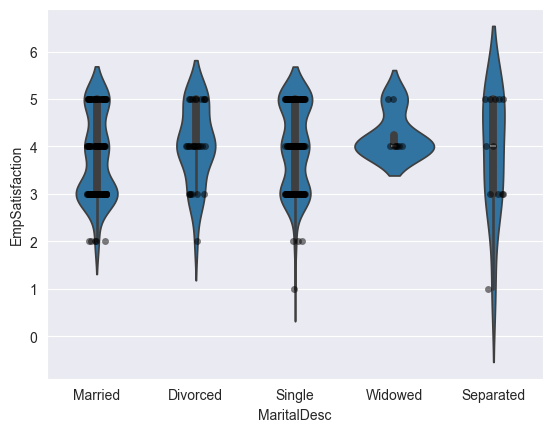

In [283]:
sns.violinplot(
    data=df,
    x="MaritalDesc",
    y="EmpSatisfaction"    
)
sns.stripplot(
    data=df,
    x="MaritalDesc",
    y="EmpSatisfaction",
    color="black",
    alpha=0.5,
    jitter=True
)

Wnioski: Nie da się stwierdzić szczególnych korealcji między zadowoleniem z pracy stanem cywilnym

4. Jak wygląda struktura wieku aktualnie zatrudnionych pracowników?


Opis wieku
count    310.000000
mean      39.558065
std        8.927695
min       26.000000
25%       32.000000
50%       38.000000
75%       45.000000
max       68.000000
Name: Age, dtype: float64


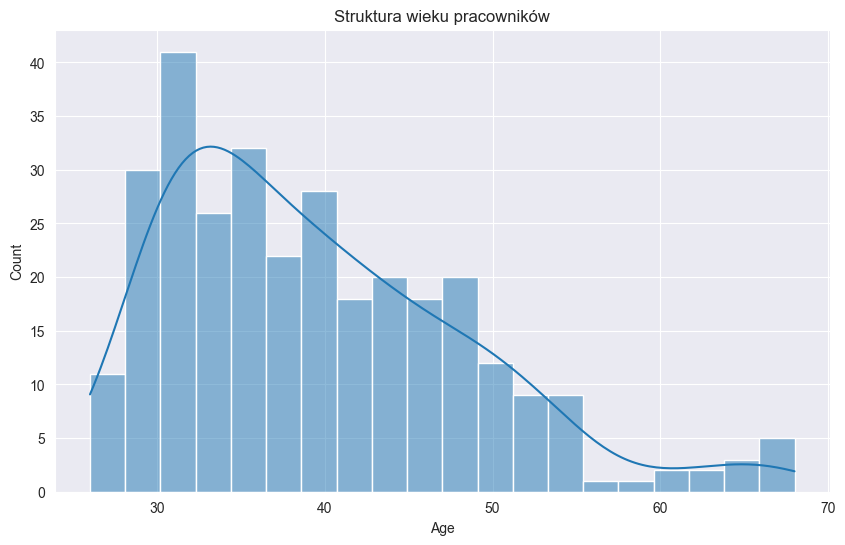

In [284]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Struktura wieku pracowników")

print("\nOpis wieku")
print(df["Age"].describe())

Wnioski: Struktura wieku wskazuje, że przedsiębiorstwo opiera się głównie na pracownikach w wieku produkcyjnym z kilkuletnim doświadczeniem zawodowym. Największą grupę stanowią osoby około 30–40 roku życia, natomiast udział najmłodszych oraz najstarszych pracowników jest niewielki.

5. Czy starsi pracownicy pracują nad większą liczbą specjalnych projektów niż młodsi pracownicy?


Korelacja
                           Age  SpecialProjectsCount
Age                   1.000000             -0.087583
SpecialProjectsCount -0.087583              1.000000


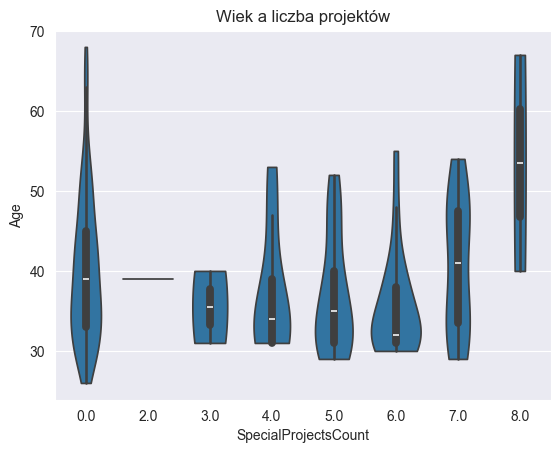

In [287]:
sns.violinplot(
    data=df,
    x="SpecialProjectsCount",
    y="Age",
    cut=0
)

plt.title("Wiek a liczba projektów")

print("\nKorelacja")
print(
    df[["Age", "SpecialProjectsCount"]].corr()
)

In [288]:
df.groupby("SpecialProjectsCount")["Age"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
SpecialProjectsCount,,,,,
0.0,242,40.082645,39.0,26.0,68.0
2.0,1,39.000000,39.0,39.0,39.0
3.0,2,35.500000,35.5,31.0,40.0
4.0,9,37.111111,34.0,31.0,53.0
5.0,21,36.952381,35.0,29.0,52.0
6.0,21,35.666667,32.0,30.0,55.0
7.0,12,40.583333,41.0,29.0,54.0
8.0,2,53.500000,53.5,40.0,67.0


Wnioski:Analiza nie wykazała istotnej zależności pomiędzy wiekiem pracownika a liczbą realizowanych projektów specjalnych. Współczynnik korelacji wynosi -0,088, co wskazuje na praktyczny brak liniowej zależności. Chociaż pracownicy realizujący 8 projektów są starsi od średniej, grupa ta liczy jedynie dwie osoby, dlatego nie można na tej podstawie wyciągać uogólnionych wniosków.